In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


In [9]:
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )


print("MGSD Test set balance:\n", sample_mgsd["label"].value_counts())
print("MGSD Few-shot examples balance:\n", sample_examples_mgsd["label"].value_counts())

print("MentalManip Test set balance:\n", sample_mentalmanip["manipulative"].value_counts())
print("MentalManip Few-shot examples balance:\n", sample_examples_mentalmanip["manipulative"].value_counts())

MGSD Test set balance:
 label
unrelated     250
stereotype    250
Name: count, dtype: int64
MGSD Few-shot examples balance:
 label
stereotype    5
unrelated     5
Name: count, dtype: int64
MentalManip Test set balance:
 manipulative
1    250
0    250
Name: count, dtype: int64
MentalManip Few-shot examples balance:
 manipulative
1    5
0    5
Name: count, dtype: int64


In [10]:
from dotenv import load_dotenv
from tree_of_thought import TreeOfThought
import openai
import os, torch, numpy as np
from utils import call_llm
import json

load_dotenv()

ENV_VARS = {
    "API_KEY_OPENAI": "OpenAI",
    "API_KEY_AZURE_OPENAI": "Azure OpenAI",
    "ENDPOINT_AZURE_OPENAI": "Azure OpenAI Endpoint",
}

for var, name in ENV_VARS.items():
    if not os.getenv(var):
        raise ValueError(f"Missing {name} API key: `{var}` must be set in the environment.")


client = openai.OpenAI(api_key= os.getenv("API_KEY_AZURE_OPENAI"))
#client = openai.AzureOpenAI(api_version="2024-12-01-preview", azure_endpoint=os.getenv("ENDPOINT_AZURE_OPENAI"), api_key=os.getenv("API_KEY_AZURE_OPENAI"),)
model = "gpt-4.1-mini"
model_filename = "openai_4.1_mini"

## Zero-shot prompting

In [ ]:
import pandas as pd
from tqdm import tqdm
import os, json
from stereotype_def import stereotype_definition_short_binary
from mentalmanip_def import mental_manipulation_def1_short
from case_studies import stereotypes, manipulation
from cases import stereotypes_case, manipulation_case
from zero_shot import ZeroShot
from sklearn.metrics import classification_report, confusion_matrix
from openai import RateLimitError

case_name_set = ["stereotype", "manipulation"]
regime = ["high"]
regime_tokens = {"low": 100, "medium": 200, "high": 300}
prompt_type = "short"
    
if True:
    for case_name in case_name_set:
        for r in regime:
            if case_name.lower() == "manipulation":
                case = manipulation_case
                task_definition = mental_manipulation_def1_short
                data = sample_mentalmanip
                output_file = f"results/{model_filename}/zero_shot/classic/results_manipulation_zero_shot_prompt_short_binary.csv"
    
            elif case_name.lower() == "stereotype":
                case = stereotypes_case
                task_definition = stereotype_definition_short_binary
                data = sample_mgsd
                output_file = f"results/{model_filename}/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv"
    
            else:
                raise ValueError(f"Unknown case name: {case_name}")
    
            os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
            #if os.path.exists(output_file):
            #    df_out_existing = pd.read_csv(output_file)
            #    done_ids = set(df_out_existing["sample_id"])
            #    rows = df_out_existing.to_dict(orient="records")
            #    print(f"=== Resuming from last index... {len(done_ids)} samples already completed.")
            #else:
            done_ids = set()
            rows = []
    
            zero_shot_classifier = ZeroShot(
                case=case,
                client=client,
                model=model,
                max_tokens=regime_tokens[r],
                task_definition=task_definition,
            )
    
            try:
                for idx, row in tqdm(data.iterrows(), total=len(data)):
                    if idx in done_ids:
                        continue
    
                    text = row[case.input_col]
                    true_label = row[case.label_col]
                    if isinstance(true_label, str):
                        true_label = true_label.strip()
    
                    try:
                        predicted_label, stats = zero_shot_classifier.classify(text)
                        mapped_label = case.label_map.get(predicted_label.strip(), list(case.label_map.values())[-1])
                    except RateLimitError as e:
                        print(f"\nRate limit hit at sample {idx}. Saving progress.")
                        break
                    except Exception as e:
                        print(f"\nError at sample {idx}: {e}. Skipping.")
                        continue
    
                    results = {
                        "sample_id": idx,
                        "text": text,
                        "true_label": true_label,
                        "pred_label": mapped_label,
                        "max_tokens": zero_shot_classifier.max_tokens,
                        "tokens_used": stats["tokens_used"],
                        "prompt_tokens": stats["prompt_tokens"],
                        "completion_tokens": stats["completion_tokens"],
                        "latency": stats["latency"],
                    }
    
                    rows.append(results)
    
            except KeyboardInterrupt:
                print("=== Interrupted manually. Saving progress...")
    
            finally:
                df_out = pd.DataFrame(rows)
            #    df_out.to_csv(output_file, index=False)
            #    print(f"✅ Saved {len(df_out)} rows to {output_file}")
    
                if case_name == "manipulation":
                    y_true = df_out["true_label"].astype(int)
                    y_pred = df_out["pred_label"].astype(int)
                elif case_name == "stereotype":
                    y_true = df_out["true_label"]
                    y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
    
                print("=== Classification Report ===\n")
                print(classification_report(y_true, y_pred))
    
                print("\n=== Confusion Matrix ===\n")
                labels = sorted(set(y_true) | set(y_pred))
                conf_matrix = confusion_matrix(y_true, y_pred)
                print(pd.DataFrame(conf_matrix, index=labels, columns=labels))
    
                accuracy = (y_true == y_pred).mean()
                print(f"\n=== Accuracy: {accuracy:.2%} ===")

  1%|          | 3/500 [00:00<01:27,  5.69it/s]


Error at sample 0: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.

Error at sample 1: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.

Error at sample 2: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.


  1%|          | 5/500 [00:00<01:05,  7.53it/s]


Error at sample 3: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.

Error at sample 4: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.

Error at sample 5: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.


  2%|▏         | 9/500 [00:01<00:52,  9.42it/s]

...

  5%|▌         | 27/500 [00:02<00:43, 10.98it/s]


Error at sample 24: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.

Error at sample 25: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.

Error at sample 26: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.


  6%|▌         | 29/500 [00:03<00:48,  9.66it/s]


Error at sample 27: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.

Error at sample 28: Error code: 401 - {'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}. Skipping.
=== Interrupted manually. Saving progress...


KeyError: 'true_label'

## Few-shots prompting

In [ ]:
import pandas as pd
from tqdm import tqdm
import os, json
from stereotype_def import stereotype_definition, stereotype_definition_short, stereotype_definition_short_binary
from mentalmanip_def import mental_manipulation_def1, mental_manipulation_def1_short
from case_studies import stereotypes, manipulation
from cases import stereotypes_case, manipulation_case
from few_shots import FewShot
from sklearn.metrics import classification_report, confusion_matrix


case_name_set = ["stereotype", "manipulation"]

regime = ["high"]
regime_tokens = {"low": 100, "medium": 200, "high": 300}
prompt_type = "short"


for case_name in case_name_set:
    for j in range(1, 6):
        try: 
            if case_name.lower() == "manipulation":
                case = manipulation_case
                task_definition = mental_manipulation_def1_short
                data = sample_mentalmanip
                examples_df = sample_examples_mentalmanip
                output_file = f"results/{model_filename}/few_shot/classic/results_manipulation_few_shot_prompt_short_{j}examples.csv"
            
            elif case_name.lower() == "stereotype":
                case = stereotypes_case
                task_definition = stereotype_definition_short_binary
                data = sample_mgsd
                examples_df = sample_examples_mgsd
                output_file = f"results/{model_filename}/few_shot/classic/results_stereotype_few_shot_prompt_short_{j}examples_binary"
            
            else:
                raise ValueError(f"Unknown case name: {case_name}")
            
            
            few_shot_classifier = FewShot(
                case=case,
                client=client,
                model=model,
                max_tokens=300,
                task_definition=task_definition, 
                n_shots=j,
                examples_df=examples_df,
            )
            
            
            rows = []
            
            
            for idx, row in tqdm(data.iterrows(), total=len(data)):
                text = row[case.input_col]
                true_label = row[case.label_col]
                
                if isinstance(true_label, str):
                    true_label = true_label.strip()
            
                predicted_label, stats = few_shot_classifier.classify(text)
                mapped_label = case.label_map.get(predicted_label.strip(), list(case.label_map.values())[-1])
            
                results = {
                    "sample_id": idx,
                    "text": text,
                    "true_label": true_label,
                    "pred_label": mapped_label,
                    "max_tokens": few_shot_classifier.max_tokens,
                    "tokens_used": stats["tokens_used"],
                    "prompt_tokens": stats["prompt_tokens"],
                    "completion_tokens": stats["completion_tokens"],
                    "latency": stats["latency"],
                }
            
                rows.append(results)
            
            
            df_out = pd.DataFrame(rows)
            df_out.to_csv(output_file, index=False)
            print(f"=== Saved {len(df_out)} rows to {output_file}")
            
            if case_name == "manipulation":
                y_true = df_out["true_label"].astype(int)
                y_pred = df_out["pred_label"].astype(int)
            
            elif case_name == "stereotype":
                y_true = df_out["true_label"]
                y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
            
            
            print("=== Classification Report ===\n")
            print(classification_report(y_true, y_pred))
            
            
            print("\n=== Confusion Matrix ===\n")
            labels = sorted(set(y_true) | set(y_pred))
            conf_matrix = confusion_matrix(y_true, y_pred)
            print(pd.DataFrame(conf_matrix, index=labels, columns=labels))
            
            accuracy = (y_true == y_pred).mean()
            print(f"\n=== Accuracy: {accuracy:.2%} ===")
            
        except Exception as e:
            print(f"Error with n_shots={j}: {e}")

=== Skipped j =  1
=== Skipped j =  2
=== Skipped j =  3
=== Skipped j =  4


100%|██████████| 500/500 [03:45<00:00,  2.22it/s]


=== Saved 500 rows to results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_5examples_binary
=== Classification Report ===

              precision    recall  f1-score   support

  stereotype       0.76      0.62      0.68       250
   unrelated       0.68      0.80      0.74       250

    accuracy                           0.71       500
   macro avg       0.72      0.71      0.71       500
weighted avg       0.72      0.71      0.71       500


=== Confusion Matrix ===

            stereotype  unrelated
stereotype         156         94
unrelated           50        200

=== Accuracy: 71.20% ===


100%|██████████| 500/500 [04:19<00:00,  1.93it/s]


=== Saved 500 rows to results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_1examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.68      0.62      0.65       250
           1       0.65      0.71      0.68       250

    accuracy                           0.66       500
   macro avg       0.67      0.66      0.66       500
weighted avg       0.67      0.66      0.66       500


=== Confusion Matrix ===

     0    1
0  155   95
1   73  177

=== Accuracy: 66.40% ===


...

=== Saved 500 rows to results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.69      0.69      0.69       250
           1       0.69      0.69      0.69       250

    accuracy                           0.69       500
   macro avg       0.69      0.69      0.69       500
weighted avg       0.69      0.69      0.69       500


=== Confusion Matrix ===

     0    1
0  172   78
1   78  172

=== Accuracy: 68.80% ===


100%|██████████| 500/500 [03:55<00:00,  2.13it/s]


=== Saved 500 rows to results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_4examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.67      0.66      0.67       250
           1       0.67      0.68      0.67       250

    accuracy                           0.67       500
   macro avg       0.67      0.67      0.67       500
weighted avg       0.67      0.67      0.67       500


=== Confusion Matrix ===

     0    1
0  165   85
1   81  169

=== Accuracy: 66.80% ===


100%|██████████| 500/500 [03:47<00:00,  2.20it/s]

=== Saved 500 rows to results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_5examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.66      0.60      0.63       250
           1       0.64      0.69      0.66       250

    accuracy                           0.65       500
   macro avg       0.65      0.65      0.65       500
weighted avg       0.65      0.65      0.65       500


=== Confusion Matrix ===

     0    1
0  151   99
1   77  173

=== Accuracy: 64.80% ===


## Zero-shot and Few-shot prompting with profile keys

In [ ]:
from data_loader import build_failure_augmented_sample
import pandas as pd

failure = True
if failure:
    #failure_path = "results/openai_4o_mini/zero_shot/medium/results_stereotype_zero_shot_prompt_short_binary.csv"
    #df_results = pd.read_csv(failure_path)
    
    df_results["true_label"] = df_results["true_label"].astype(str).str.strip().str.lower()
    df_results["pred_label"] = df_results["pred_label"].astype(str).str.strip().str.lower()
    
    df_failures = df_results[df_results["true_label"] != df_results["pred_label"]]
    
    failed_ids = df_failures["sample_id"].tolist()
    
    # === Save to file
    #pd.Series(failed_ids).to_csv("failure_ids_stereotype.csv", index=False)
    
    sample_mgsd = build_failure_augmented_sample(
        full_df=df[df["label"].isin(["stereotype", "unrelated"])],
        label_col="label",
        failure_ids=failed_ids,
        total_size=100,
        n_failures_to_include=20,
        random_state=42
    )

FileNotFoundError: [Errno 2] No such file or directory: 'results/openai_4o_mini/zero_shot/medium/results_stereotype_zero_shot_prompt_short_binary.csv'

In [ ]:
import pandas as pd
from tqdm import tqdm
import os, json
from stereotype_def import stereotype_definition_short_binary
from mentalmanip_def import mental_manipulation_def1_short
from case_studies import stereotypes, manipulation
from cases import stereotypes_case, manipulation_case
from zero_shot import ZeroShot
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from openai import RateLimitError
from few_shots import FewShot

selected_profiles = [
    #"profile1", "profile2", "profile5",  "profile10", 
    "profile12", "profile15",  # Negative
    "profile17", "profile21", "profile24",  # Neutral
]
prompt_type = "short"
task_definition = stereotype_definition_short_binary
case = stereotypes_case
max_tokens = 300

for person_key in selected_profiles:
    for role_playing in ["active"]: #,  "passive"
        for setting in ["zero_shot", "few_shot"]:

            if setting == "zero_shot" and person_key=="profile1":
                print("Skipped zero shot for profile 1")
                continue

            if setting == "zero_shot":

                output_file = f"results/{model_filename}/{setting}/role_playing/{person_key}_{role_playing}/results_stereotype_{setting}_prompt_short_binary.csv"
                os.makedirs(os.path.dirname(output_file), exist_ok=True)

                classifier = ZeroShot(
                    case=case,
                    client=client,
                    model=model,
                    max_tokens=max_tokens,
                    task_definition=task_definition,
                    person_key=person_key,
                    role_playing=role_playing,
                )
            else:

                output_file = f"results/{model_filename}/{setting}/role_playing/{person_key}_{role_playing}/results_stereotype_{setting}_prompt_short_3examples_binary.csv"
                os.makedirs(os.path.dirname(output_file), exist_ok=True)

                from data_loader import load_mgsd_dataset
                _, few_shot_examples = load_mgsd_dataset(
                    df,
                    {"stereotype": 5, "unrelated": 5},
                    {"stereotype": 5, "unrelated": 5},
                    random_state=0,
                    random_state_examples=1
                )

                classifier = FewShot(
                    case=case,
                    client=client,
                    model=model,
                    max_tokens=max_tokens,
                    task_definition=task_definition,
                    n_shots=3,
                    examples_df=few_shot_examples,
                    person_key=person_key,
                    role_playing=role_playing,
                )

            rows = []
            for idx, row in tqdm(sample_mgsd.iterrows(), total=len(sample_mgsd), desc=f"{person_key} | {setting} | {role_playing}"):
                text = row[case.input_col]
                true_label = row[case.label_col]
                pred, stats = classifier.classify(text)
                mapped = case.label_map.get(pred.strip(), list(case.label_map.values())[-1])

                rows.append({
                    "sample_id": idx,
                    "text": text,
                    "true_label": true_label,
                    "pred_label": mapped,
                    "max_tokens": classifier.max_tokens,
                    "tokens_used": stats["tokens_used"],
                    "prompt_tokens":  stats["prompt_tokens"],
                    "completion_tokens": stats["completion_tokens"],
                    "latency": stats["latency"],
                })

            df_out = pd.DataFrame(rows)
            df_out.to_csv(output_file, index=False)
            print(f"✅ Saved {len(df_out)} rows to {output_file}")

            y_true = df_out["true_label"].astype(str).str.strip().str.lower()
            y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
            print(classification_report(y_true, y_pred))
            print(confusion_matrix(y_true, y_pred))

            accuracy = accuracy_score(y_true, y_pred)
            print(f"🔍 Accuracy for {person_key} | {setting} | {role_playing}: {accuracy:.3f}")


Skipped zero shot for profile 1


profile1 | few_shot | active: 100%|██████████| 500/500 [03:46<00:00,  2.21it/s]


✅ Saved 500 rows to results/openai_4.1_mini/few_shot/role_playing/profile1_active/results_stereotype_few_shot_prompt_short_3examples_binary.csv
              precision    recall  f1-score   support

  stereotype       0.76      0.60      0.67       250
   unrelated       0.67      0.80      0.73       250

    accuracy                           0.70       500
   macro avg       0.71      0.70      0.70       500
weighted avg       0.71      0.70      0.70       500

[[151  99]
 [ 49 201]]
🔍 Accuracy for profile1 | few_shot | active: 0.704
Skipped zero shot for profile 1


profile1 | few_shot | passive: 100%|██████████| 500/500 [03:44<00:00,  2.22it/s]


✅ Saved 500 rows to results/openai_4.1_mini/few_shot/role_playing/profile1_passive/results_stereotype_few_shot_prompt_short_3examples_binary.csv
              precision    recall  f1-score   support

  stereotype       0.74      0.62      0.67       250
   unrelated       0.67      0.78      0.72       250

    accuracy                           0.70       500
   macro avg       0.71      0.70      0.70       500
weighted avg       0.71      0.70      0.70       500

[[154  96]
 [ 54 196]]
🔍 Accuracy for profile1 | few_shot | passive: 0.700


...

✅ Saved 500 rows to results/openai_4.1_mini/zero_shot/role_playing/profile10_passive/results_stereotype_zero_shot_prompt_short_binary.csv
              precision    recall  f1-score   support

  stereotype       0.78      0.56      0.66       250
   unrelated       0.66      0.84      0.74       250

    accuracy                           0.70       500
   macro avg       0.72      0.70      0.70       500
weighted avg       0.72      0.70      0.70       500

[[141 109]
 [ 39 211]]
🔍 Accuracy for profile10 | zero_shot | passive: 0.704


profile10 | few_shot | passive: 100%|██████████| 500/500 [03:42<00:00,  2.25it/s]


✅ Saved 500 rows to results/openai_4.1_mini/few_shot/role_playing/profile10_passive/results_stereotype_few_shot_prompt_short_3examples_binary.csv
              precision    recall  f1-score   support

  stereotype       0.74      0.58      0.65       250
   unrelated       0.66      0.80      0.72       250

    accuracy                           0.69       500
   macro avg       0.70      0.69      0.69       500
weighted avg       0.70      0.69      0.69       500

[[145 105]
 [ 50 200]]
🔍 Accuracy for profile10 | few_shot | passive: 0.690


profile12 | zero_shot | active:  25%|██▍       | 124/500 [00:52<02:39,  2.36it/s]


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
from sklearn.metrics import classification_report

def parse_metadata_from_path(path):
    parts = path.split(os.sep)
    
    if "profile_result" not in parts:
        return None

    # Dynamically find the position of profile_result
    idx = parts.index("profile_result")

    try:
        profile_part = parts[idx + 1]
        method_part = parts[idx - 1]
    except IndexError:
        return None

    profile = profile_part.split("_")[0]  # "profile2"
    role = profile_part.split("_")[1]     # "active" or "passive"

    if method_part.startswith("few_"):
        shot = int(method_part.split("_")[1])
        method = "few_shot"
    elif method_part == "zero_shot":
        shot = 0
        method = "zero_shot"
    else:
        return None

    return profile, role, method, shot

def collect_results(results_dir):
    rows = []
    for root, _, files in os.walk(results_dir):
        for file in files:
            if not file.endswith(".csv"):
                continue
            full_path = os.path.join(root, file)
            metadata = parse_metadata_from_path(full_path)
            if metadata is None:
                continue

            df = pd.read_csv(full_path)
            y_true = df["true_label"].astype(str).str.lower().str.strip()
            y_pred = df["pred_label"].astype(str).str.lower().str.strip()

            report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
            accuracy = report["accuracy"]
            macro_f1 = report["macro avg"]["f1-score"]

            profile, role, method, shot = metadata
            rows.append({
                "profile": profile,
                "role": role,
                "method": method,
                "n_shots": shot,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
            })

    return pd.DataFrame(rows)

# === Usage
results_dir = "results/openai_4.1_mini/zero_shot/profile_result/profile2_active"
summary_df = collect_results(results_dir)

# Optional: sort or save
summary_df = summary_df.sort_values(by=["profile", "method", "n_shots"])
summary_df.to_csv("summary_metrics.csv", index=False)


In [ ]:
out_file = "results/zero_shot/low/results_stereotype_zero_shot_prompt_short_binary.csv"
original_df = pd.read_csv(out_file)
y_true = original_df["true_label"]
y_pred = original_df["pred_label"].astype(str).str.strip().str.lower()

print("=== Classification Report ===\n")
print(classification_report(y_true, y_pred))

print("\n=== Confusion Matrix ===\n")
labels = sorted(set(y_true) | set(y_pred))
conf_matrix = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

accuracy = (y_true == y_pred).mean()
print(f"\n=== Accuracy: {accuracy:.2%} ===")

=== Classification Report ===

              precision    recall  f1-score   support

  stereotype       0.73      0.61      0.67       250
   unrelated       0.67      0.78      0.72       250

    accuracy                           0.69       500
   macro avg       0.70      0.69      0.69       500
weighted avg       0.70      0.69      0.69       500


=== Confusion Matrix ===

            stereotype  unrelated
stereotype         152         98
unrelated           55        195

=== Accuracy: 69.40% ===


## Results analysis


=== Regime: HIGH, Shots: 1 ===
              precision    recall  f1-score   support

           0      0.706     0.600     0.649        40
           1      0.758     0.833     0.794        60

    accuracy                          0.740       100
   macro avg      0.732     0.717     0.721       100
weighted avg      0.737     0.740     0.736       100


=== Regime: HIGH, Shots: 2 ===
              precision    recall  f1-score   support

           0      0.595     0.625     0.610        40
           1      0.741     0.717     0.729        60

    accuracy                          0.680       100
   macro avg      0.668     0.671     0.669       100
weighted avg      0.683     0.680     0.681       100


=== Regime: HIGH, Shots: 3 ===
              precision    recall  f1-score   support

           0      0.630     0.725     0.674        40
           1      0.796     0.717     0.754        60

    accuracy                          0.720       100
   macro avg      0.713     0.72

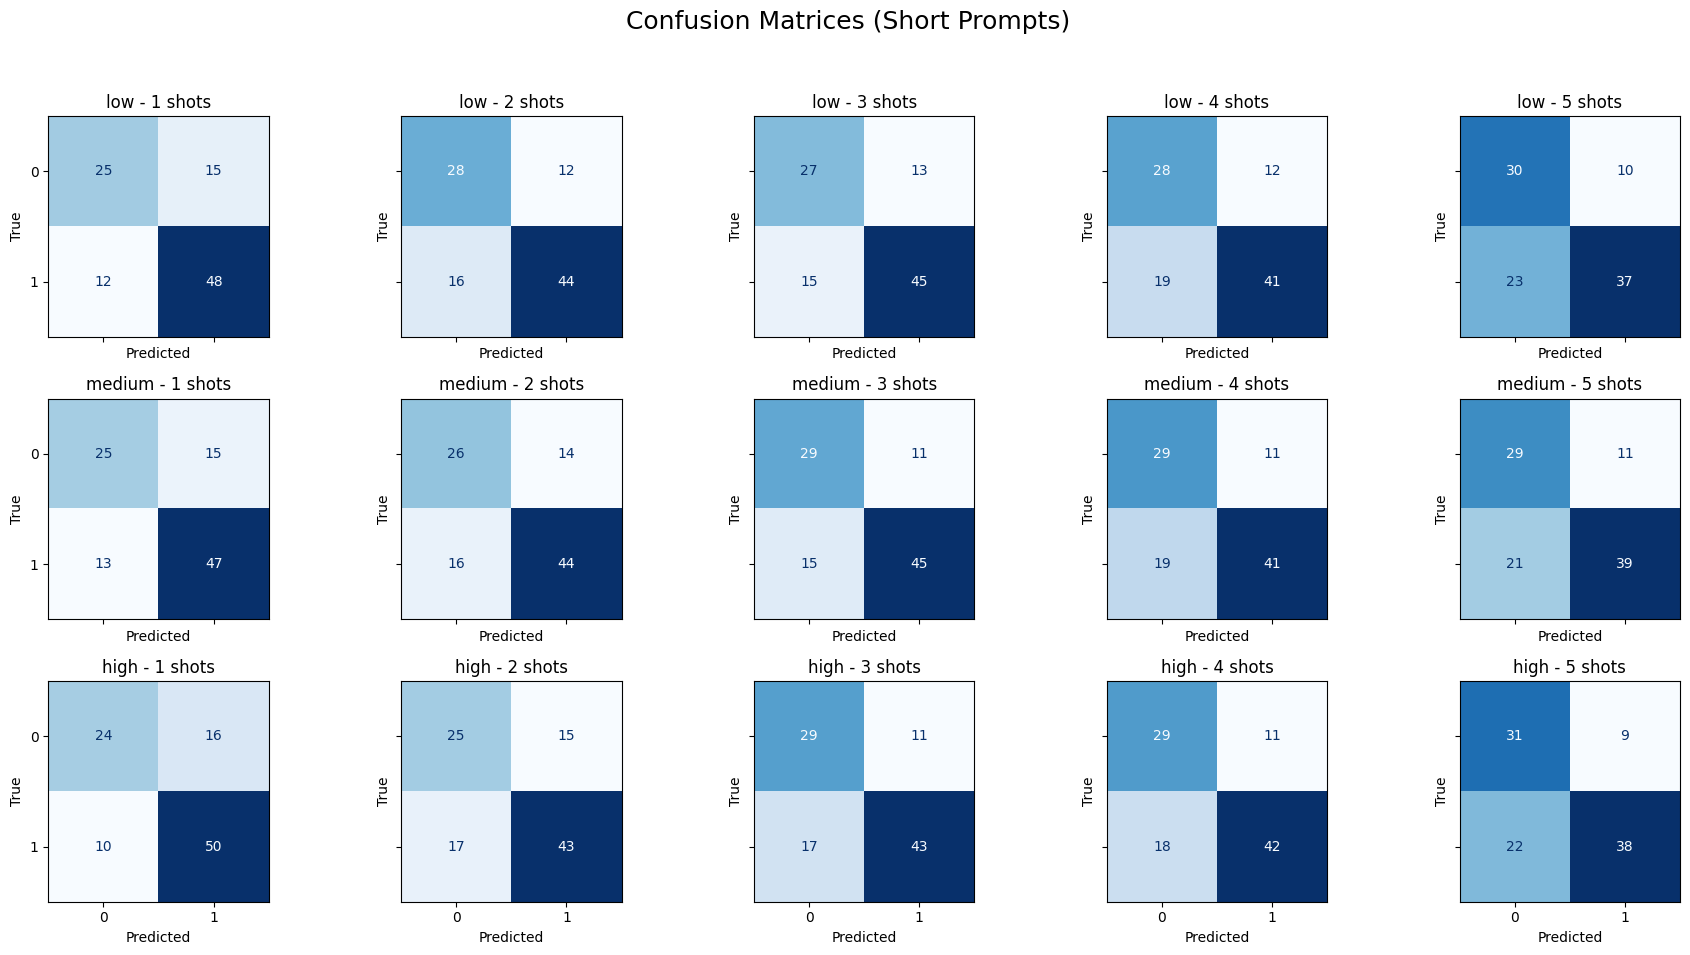


=== Accuracy Table ===

n_shots     1     2     3     4     5
regime                               
high     0.74  0.68  0.72  0.71  0.69
low      0.73  0.72  0.72  0.69  0.67
medium   0.72  0.70  0.74  0.70  0.68


In [43]:
import pandas as pd
import os
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_dir = "results"
records = []

for regime in ["low", "medium", "high"]:
    regime_path = os.path.join(results_dir, regime)
    for file in os.listdir(regime_path):
        if "manipulation_few_shot_prompt_short" in file and file.endswith(".csv"):
            match = re.search(r"short_(\d)examples", file)
            if not match:
                continue
            n_shots = int(match.group(1))
            df = pd.read_csv(os.path.join(regime_path, file))
            df["regime"] = regime
            df["n_shots"] = n_shots
            df["length"] = "long"
            records.append(df)


long_results = pd.concat(records, ignore_index=True)

grouped = long_results.groupby(["regime", "n_shots"])

for (regime, n_shots), group in grouped:
    print(f"\n=== Regime: {regime.upper()}, Shots: {n_shots} ===")
    y_true = group["true_label"].astype(int)
    y_pred = group["pred_label"].astype(int)
    print(classification_report(y_true, y_pred, digits=3))

def plot_confusion_matrix_sklearn(y_true, y_pred, title="Confusion Matrix", ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(3, 5, figsize=(18, 10), sharex=True, sharey=True)
regimes = ["low", "medium", "high"]

for i, regime in enumerate(regimes):
    for j, shots in enumerate(range(1, 6)):
        ax = axes[i, j]
        subset = long_results[(long_results["regime"] == regime) & (long_results["n_shots"] == shots)]
        if not subset.empty:
            y_true = subset["true_label"].astype(int)
            y_pred = subset["pred_label"].astype(int)
            plot_confusion_matrix_sklearn(y_true, y_pred, title=f"{regime} - {shots} shots", ax=ax)
        else:
            ax.axis("off")

fig.suptitle("Confusion Matrices (Short Prompts)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

summary = (
    long_results
    .assign(correct=lambda df: df["true_label"] == df["pred_label"])
    .groupby(["regime", "n_shots"])
    .agg(accuracy=("correct", "mean"), count=("correct", "size"))
    .reset_index()
)

print("\n=== Accuracy Table ===\n")
print(summary.pivot(index="regime", columns="n_shots", values="accuracy").round(3))




=== Regime: HIGH, Shots: 1 ===
              precision    recall  f1-score   support

           0      0.639     0.575     0.605        40
           1      0.734     0.783     0.758        60

    accuracy                          0.700       100
   macro avg      0.687     0.679     0.682       100
weighted avg      0.696     0.700     0.697       100


=== Regime: HIGH, Shots: 2 ===
              precision    recall  f1-score   support

           0      0.617     0.725     0.667        40
           1      0.792     0.700     0.743        60

    accuracy                          0.710       100
   macro avg      0.705     0.712     0.705       100
weighted avg      0.722     0.710     0.713       100


=== Regime: HIGH, Shots: 3 ===
              precision    recall  f1-score   support

           0      0.628     0.675     0.651        40
           1      0.772     0.733     0.752        60

    accuracy                          0.710       100
   macro avg      0.700     0.70

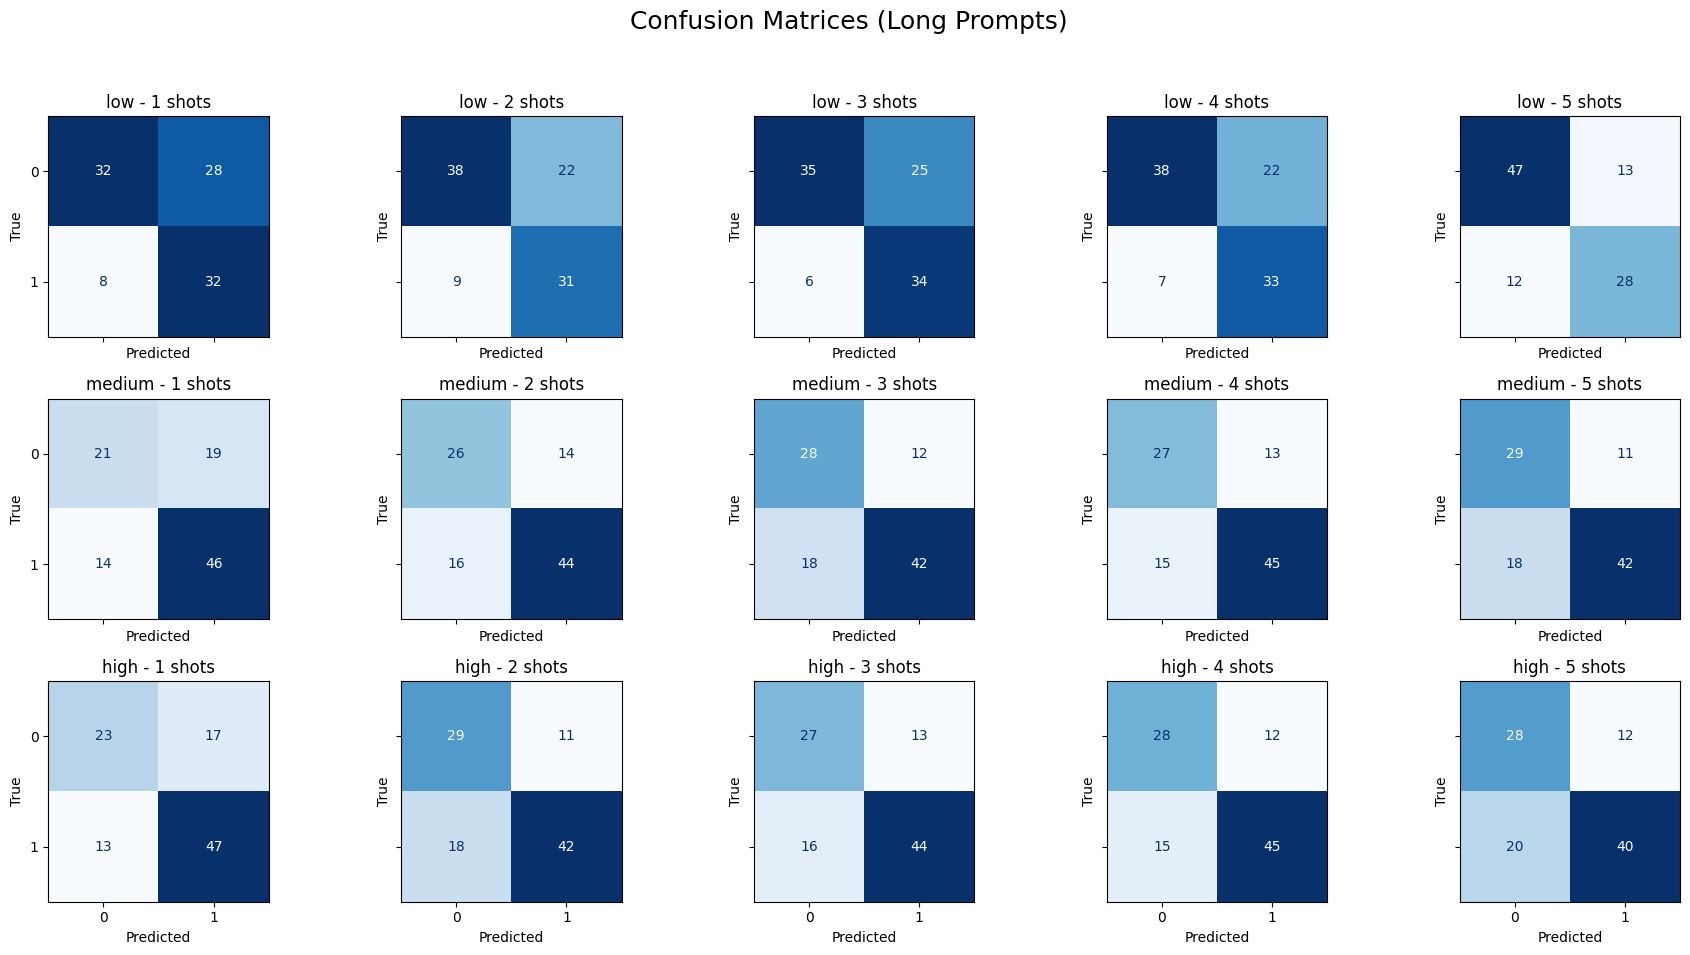


=== Accuracy Table ===

n_shots     1     2     3     4     5
regime                               
high     0.70  0.71  0.71  0.73  0.68
low      0.64  0.69  0.69  0.71  0.75
medium   0.67  0.70  0.70  0.72  0.71


In [42]:
import pandas as pd
import os
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_dir = "results"
records = []

for regime in ["low", "medium", "high"]:
    regime_path = os.path.join(results_dir, regime)
    for file in os.listdir(regime_path):
        if "manipulation_few_shot_prompt_long" in file and file.endswith(".csv"):
            match = re.search(r"long_(\d)examples", file)
            if not match:
                continue
            n_shots = int(match.group(1))
            df = pd.read_csv(os.path.join(regime_path, file))
            df["regime"] = regime
            df["n_shots"] = n_shots
            df["length"] = "long"
            records.append(df)


long_results = pd.concat(records, ignore_index=True)

grouped = long_results.groupby(["regime", "n_shots"])

for (regime, n_shots), group in grouped:
    print(f"\n=== Regime: {regime.upper()}, Shots: {n_shots} ===")
    y_true = group["true_label"].astype(int)
    y_pred = group["pred_label"].astype(int)
    print(classification_report(y_true, y_pred, digits=3))

def plot_confusion_matrix_sklearn(y_true, y_pred, title="Confusion Matrix", ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(3, 5, figsize=(18, 10), sharex=True, sharey=True)
regimes = ["low", "medium", "high"]

for i, regime in enumerate(regimes):
    for j, shots in enumerate(range(1, 6)):
        ax = axes[i, j]
        subset = long_results[(long_results["regime"] == regime) & (long_results["n_shots"] == shots)]
        if not subset.empty:
            y_true = subset["true_label"].astype(int)
            y_pred = subset["pred_label"].astype(int)
            plot_confusion_matrix_sklearn(y_true, y_pred, title=f"{regime} - {shots} shots", ax=ax)
        else:
            ax.axis("off")

fig.suptitle("Confusion Matrices (Long Prompts)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

summary = (
    long_results
    .assign(correct=lambda df: df["true_label"] == df["pred_label"])
    .groupby(["regime", "n_shots"])
    .agg(accuracy=("correct", "mean"), count=("correct", "size"))
    .reset_index()
)

print("\n=== Accuracy Table ===\n")
print(summary.pivot(index="regime", columns="n_shots", values="accuracy").round(3))
